In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("creditcard.csv.zip")

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
X = df.drop("Class", axis=1)
y = df["Class"]

print(X.shape)
print(y.shape)

(284807, 30)
(284807,)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train-Test Split Successful")

Train-Test Split Successful


In [8]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [9]:
log_model = LogisticRegression(
    max_iter=500,
    solver="liblinear",
    random_state=42
)

log_model.fit(X_train_smote, y_train_smote)

log_pred = log_model.predict(X_test)

log_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [10]:
print("Precision:", precision_score(y_test, log_pred))
print("Recall:", recall_score(y_test, log_pred))
print("F1 Score:", f1_score(y_test, log_pred))
print("ROC AUC:", roc_auc_score(y_test, log_prob))

print("\nClassification Report:\n")
print(classification_report(y_test, log_pred))

Precision: 0.07331136738056013
Recall: 0.9081632653061225
F1 Score: 0.13567073170731708
ROC AUC: 0.973175255963387

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



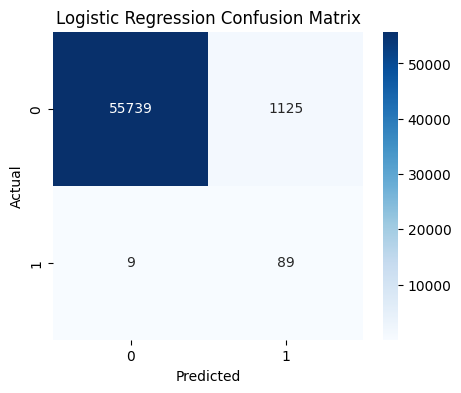

In [11]:
cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [12]:
from sklearn.tree import DecisionTreeClassifier

In [13]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=6
)

dt_model.fit(X_train_smote, y_train_smote)

dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [14]:
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))
print("ROC AUC:", roc_auc_score(y_test, dt_prob))

print(classification_report(y_test, dt_pred))

Precision: 0.07106598984771574
Recall: 0.8571428571428571
F1 Score: 0.13125
ROC AUC: 0.952045087168238
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.86      0.13        98

    accuracy                           0.98     56962
   macro avg       0.54      0.92      0.56     56962
weighted avg       1.00      0.98      0.99     56962



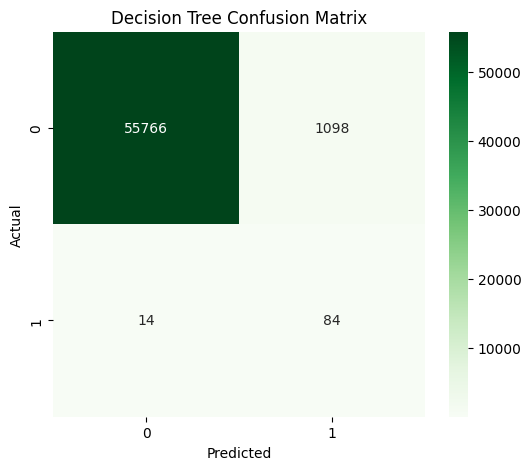

In [15]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

<Figure size 800x600 with 0 Axes>

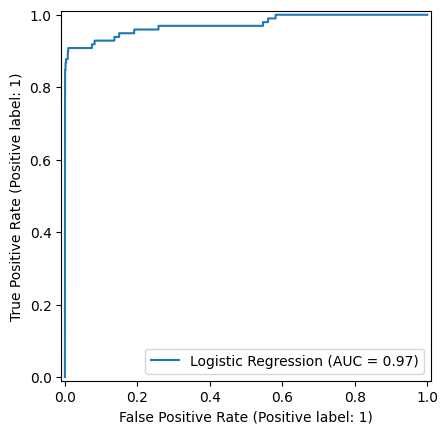

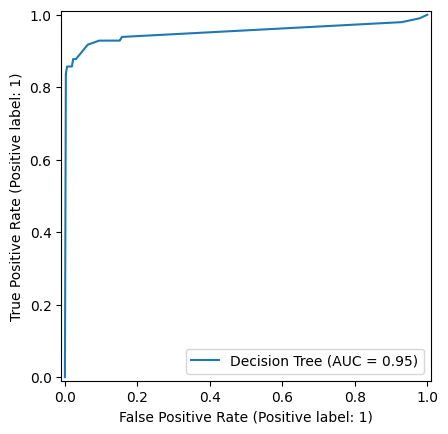

In [16]:
plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(
    log_model,
    X_test,
    y_test,
    name="Logistic Regression"
)

RocCurveDisplay.from_estimator(
    dt_model,
    X_test,
    y_test,
    name="Decision Tree"
)

plt.show()

In [17]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
14,V14,0.872920
4,V4,0.049342
17,V17,0.025790
1,V1,0.011162
12,V12,0.007557
13,V13,0.007120
3,V3,0.004507
28,V28,0.004380
10,V10,0.003167
15,V15,0.002999


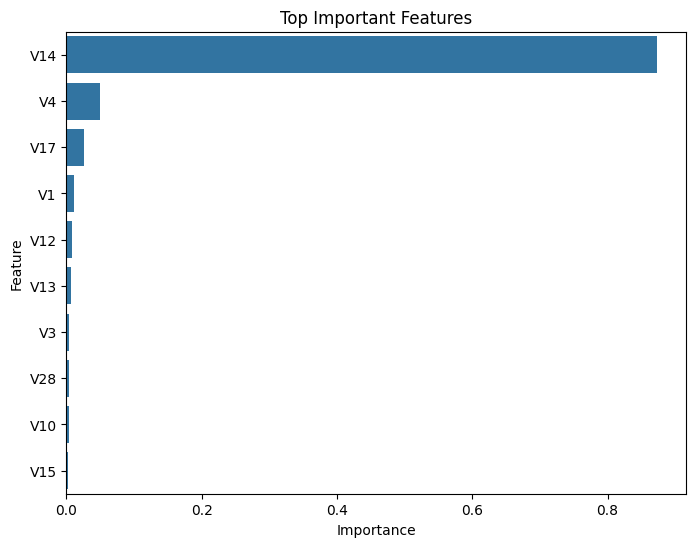

In [18]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Important Features")

plt.show()

In [19]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Precision":[
        precision_score(y_test, log_pred),
        precision_score(y_test, dt_pred)
    ],

    "Recall":[
        recall_score(y_test, log_pred),
        recall_score(y_test, dt_pred)
    ],

    "F1 Score":[
        f1_score(y_test, log_pred),
        f1_score(y_test, dt_pred)
    ],

    "ROC AUC":[
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, dt_prob)
    ]

})

comparison

,Model,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.073311,0.908163,0.135671,0.973175
1,Decision Tree,0.071066,0.857143,0.131250,0.952045


In [20]:
#conclusion : Decision Tree achieved good fraud detection performance while being computationally efficient. It is suitable for deployment where fast predictions are required.